In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from train_model import SegNet, ARMultiAnnDataset, collate_var, FNAME_RE
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from train_model import SegNet, ARMultiAnnDataset, collate_var, FNAME_RE
from sklearn.metrics import jaccard_score
import numpy as np
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import arviz as az
import os
import xarray as xr
import cartopy.crs as ccrs
import pickle
import math


In [2]:
torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.cuda.get_device_name()

'Tesla V100-PCIE-32GB'

In [3]:
class SelfAttentionForSpatialData(nn.Module):
    """
    A self-attention model to find similarities in spatial data.
    """
    def __init__(self, input_dim, d_model=128, nhead=4):
        """
        Initializes the self-attention model.

        Args:
            input_dim (int): The number of features for each location (e.g., 1 for just TMQ).
            d_model (int): The dimensionality of the model's internal representations.
            nhead (int): The number of attention heads.
        """
        super(SelfAttentionForSpatialData, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Linear(input_dim, d_model)
        self.attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead, batch_first=True)

    def forward(self, x):
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): The input tensor of shape (batch_size, sequence_length, input_dim).

        Returns:
            torch.Tensor: The attention output of shape (batch_size, sequence_length, d_model).
            torch.Tensor: The attention weights of shape (batch_size, sequence_length, sequence_length).
        """
        # Embed the input features
        x_embedded = self.embedding(x)

        # Get attention output and weights
        attn_output, attn_weights = self.attention(x_embedded, x_embedded, x_embedded)

        return attn_output, attn_weights

In [4]:
# ─── dataset & loader (batch_size = 1 keeps y_lists as Python lists) ───
ds = ARMultiAnnDataset(
        root        = "/home/sbk29/data/AR/train",
        var_names   = ["TMQ"],
        gt_npy_root = "/home/sbk29/data/github_AR/AR_detection/u_net/ds_results"
)
dl = DataLoader(
        ds, batch_size=1, shuffle=False,
        collate_fn=collate_var, pin_memory=(device == "cuda")
)

In [5]:
tmq = []

In [6]:
for x_vars, y_lists, y_cons, y_mean in dl:
    x_vars_np = np.array(x_vars)
    
    tmq.append(x_vars.cpu().numpy())

In [7]:
tmq = np.array(tmq)

In [8]:
tmq_data = tmq.squeeze()

In [9]:
tmq_data.shape

(188, 768, 1152)

In [11]:
tmq_data.shape

(188, 768, 1152)

In [11]:
from sklearn.cluster import MeanShift, estimate_bandwidth

Reshaping data into a list of pixel values...
Estimating bandwidth...
Estimated bandwidth: 5.915
Performing mean shift clustering...
Number of estimated clusters: 2


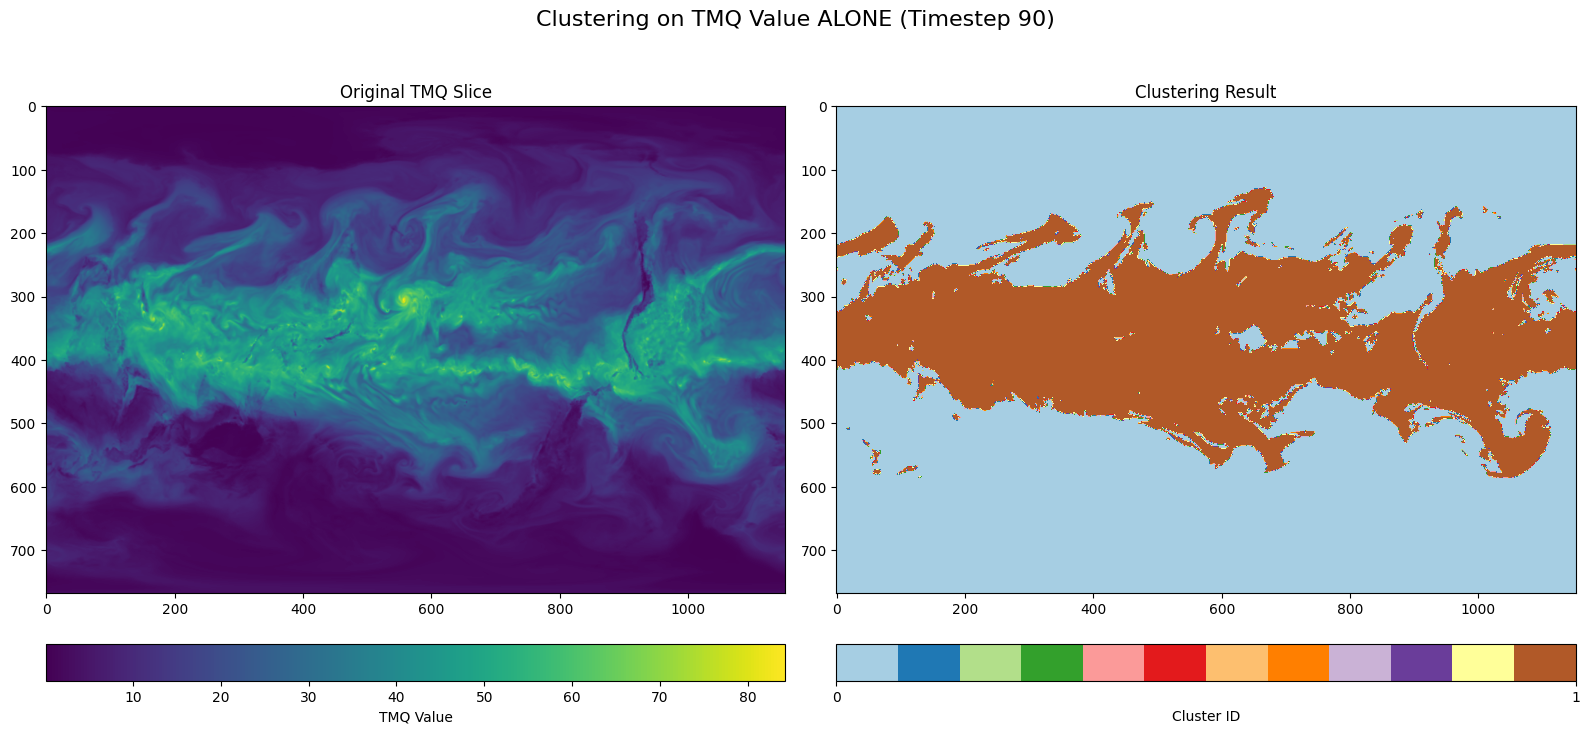

In [12]:
# --- 2. Select a Time Slice to Analyze ---
TIMESTEP_TO_ANALYZE = 90
selected_tmq_slice = tmq_data[TIMESTEP_TO_ANALYZE, :, :]

# --- 3. THE ABSOLUTE MINIMUM PREPARATION ---
# Reshape the (H, W) image into a list of pixels (H * W, 1).
# This is the only required preparation step.
print("Reshaping data into a list of pixel values...")
data_for_clustering = selected_tmq_slice.reshape(-1, 1) # -1 automatically calculates H*W

# --- 4. Perform Clustering on Pixel Values Only ---
print("Estimating bandwidth...")
# The bandwidth is now just a threshold on the TMQ values themselves.
bandwidth = estimate_bandwidth(data_for_clustering, quantile=0.2, n_samples=1000)
print(f"Estimated bandwidth: {bandwidth:.3f}")

print("Performing mean shift clustering...")
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(data_for_clustering)

labels = ms.labels_
n_clusters = len(np.unique(labels))
print(f"Number of estimated clusters: {n_clusters}")

# --- 5. Visualize the Results ---
# Reshape the flat list of labels back into the original image shape
segmented_image = labels.reshape(selected_tmq_slice.shape)

# Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle(f'Clustering on TMQ Value ALONE (Timestep {TIMESTEP_TO_ANALYZE})', fontsize=16)

ax1.set_title('Original TMQ Slice')
im1 = ax1.imshow(selected_tmq_slice, cmap='viridis', aspect='auto')
fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.08, label='TMQ Value')

ax2.set_title('Clustering Result')
im2 = ax2.imshow(segmented_image, cmap='Paired', aspect='auto')
cbar = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.08, label='Cluster ID')
if n_clusters > 0:
    cbar.set_ticks(np.arange(0, n_clusters))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [24]:
# --- 3. PREPARATION: Normalize Data to 8-bit Integer (0-255) ---
TIMESTEP_TO_ANALYZE = 90
# selected_tmq_slice = tmq_data[TIMESTEP_TO_ANALYZE, :, :]

# Your TMQ slice has floating point values (e.g., -5.0 to 60.0)
selected_tmq_slice = tmq_data[TIMESTEP_TO_ANALYZE, :, :]

# 1. We find the real minimum and maximum TMQ values in your slice.
min_val = selected_tmq_slice.min() # e.g., -5.0
max_val = selected_tmq_slice.max() # e.g., 60.0

# 2. We perform a linear scaling. This is the magic step.
#    - The lowest TMQ value (-5.0) will be mapped to 0.
#    - The highest TMQ value (60.0) will be mapped to 255.
#    - All other TMQ values are scaled proportionally in between.
scaled_slice = 255 * (selected_tmq_slice - min_val) / (max_val - min_val)

# 3. We convert the new floating-point values (now between 0.0 and 255.0)
#    into the required 8-bit integer data type.
image_8bit = selected_tmq_slice.astype(np.uint8)

# Now, 'image_8bit' is a version of your TMQ data that looks like a
# grayscale image to the edge detection functions.

In [25]:
import cv2
from skimage.feature import canny

Applying Sobel operator...
Applying Canny edge detector...


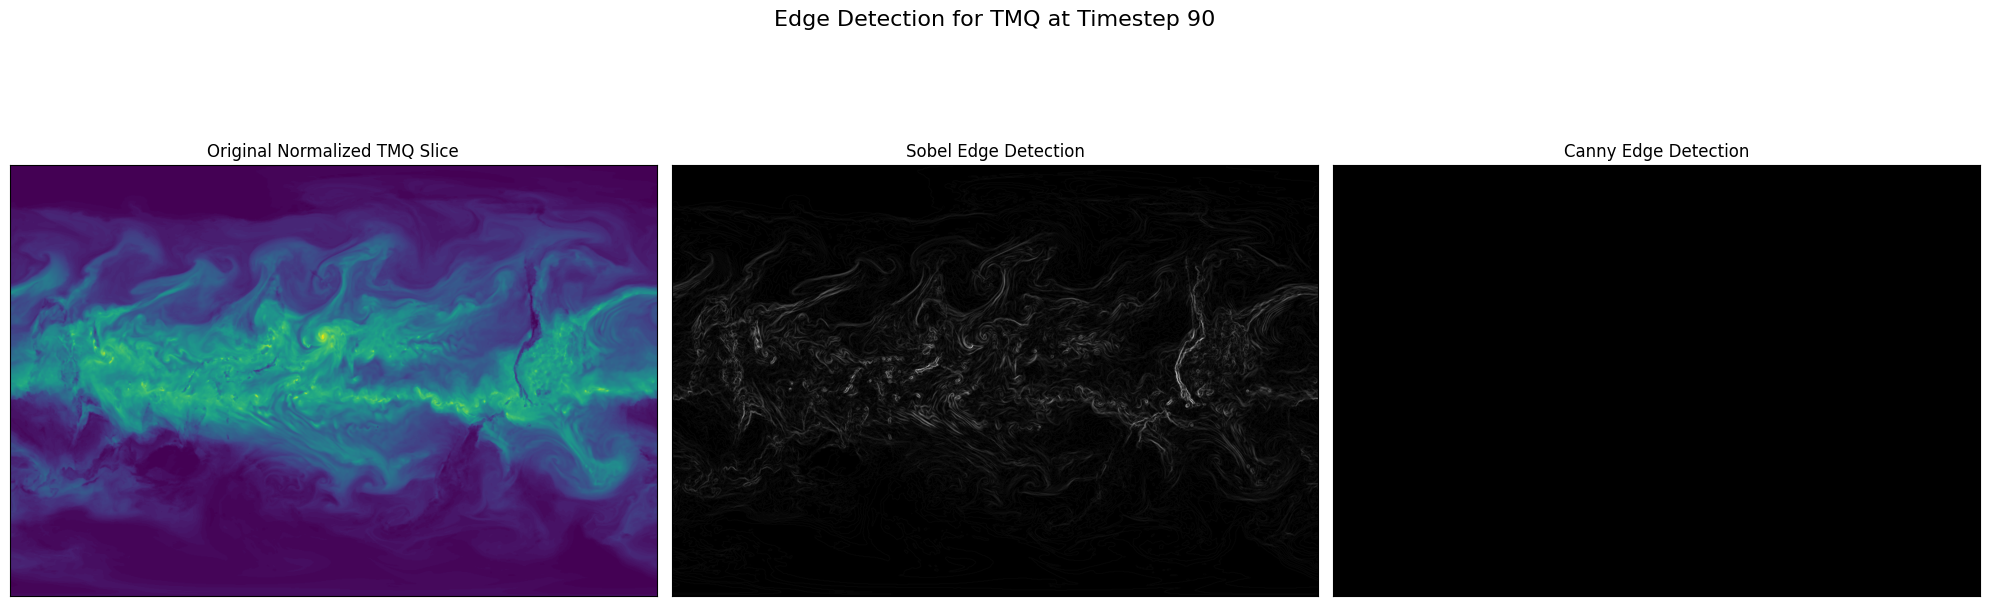

In [32]:
# --- 4. Apply Edge Detection Algorithms ---

# Method A: Sobel Operator (using OpenCV)
print("Applying Sobel operator...")
# Calculate gradients along x and y axes
sobelx = cv2.Sobel(image_8bit, cv2.CV_64F, 1, 0, ksize=1) # x
sobely = cv2.Sobel(image_8bit, cv2.CV_64F, 0, 1, ksize=1) # y
# Combine the gradients to get the magnitude
sobel_combined = np.sqrt(sobelx**2 + sobely**2)
# Normalize to 0-255 to display properly
sobel_combined = cv2.normalize(sobel_combined, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


# Method B: Canny Edge Detector (using scikit-image for simplicity)
print("Applying Canny edge detector...")
# The 'sigma' parameter controls the amount of Gaussian blurring.
# Higher sigma means less detail/noise.
# The low and high thresholds are used for hysteresis tracking.
edges_canny = canny(image_8bit, sigma=2, low_threshold=1, high_threshold=50)


# --- 5. Visualize the Results ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharex=True, sharey=True)
ax = axes.ravel()

fig.suptitle(f'Edge Detection for TMQ at Timestep {TIMESTEP_TO_ANALYZE}', fontsize=16)

ax[0].imshow(image_8bit, cmap='viridis')
ax[0].set_title('Original Normalized TMQ Slice')

ax[1].imshow(sobel_combined, cmap='gray')
ax[1].set_title('Sobel Edge Detection')

ax[2].imshow(edges_canny, cmap='gray')
ax[2].set_title('Canny Edge Detection')

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [33]:
import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
from geopy.distance import great_circle
from geopy.point import Point

# Helper function from above
def find_radial_point(lat, lon, bearing, distance_km):
    start_point = Point(latitude=lat, longitude=lon)
    destination = great_circle(kilometers=distance_km).destination(start_point, bearing)
    return destination.latitude, destination.longitude

def calculate_custom_laplacian(tmq_slice, lats, lons, distance_deg):
    """
    Calculates the Laplacian using a large, 8-point radial stencil.

    Args:
        tmq_slice (np.ndarray): 2D (H, W) array of TMQ/IVT data.
        lats (np.ndarray): 1D array of latitude values for the grid.
        lons (np.ndarray): 1D array of longitude values for the grid.
        distance_deg (float): The Great Circle Distance for the stencil in degrees.

    Returns:
        np.ndarray: A 2D (H, W) array of Laplacian values.
    """
    H, W = tmq_slice.shape
    laplacian_field = np.zeros_like(tmq_slice, dtype=np.float64)
    
    # Convert distance from degrees to kilometers and radians
    distance_km = distance_deg * 111.1 # Rough conversion: 1 degree approx 111.1 km
    distance_rad = np.deg2rad(distance_deg)

    # Create coordinate arrays for interpolation
    # NOTE: map_coordinates expects coordinates in (row, col) pixel format
    h_coords = np.arange(H)
    w_coords = np.arange(W)
    
    # Bearings for the 8 radial points (N, NE, E, SE, S, SW, W, NW)
    bearings = [0, 45, 90, 135, 180, 225, 270, 315]

    print("Calculating custom Laplacian... (This will be slow on large grids)")
    # Iterate over each grid cell to calculate its Laplacian
    # NOTE: This loop is for clarity. For performance, this would be vectorized.
    for i in range(H):
        for j in range(W):
            center_lat, center_lon = lats[i], lons[j]
            center_value = tmq_slice[i, j]
            
            # Find the 8 surrounding points and their values via interpolation
            radial_points_coords = [find_radial_point(center_lat, center_lon, b, distance_km) for b in bearings]
            
            # Convert destination lat/lons to grid indices (row, col)
            # This requires knowing the grid resolution
            dest_lats, dest_lons = zip(*radial_points_coords)
            dest_rows = np.interp(dest_lats, lats, h_coords)
            dest_cols = np.interp(dest_lons, lons, w_coords)
            
            # Interpolate the TMQ values at these 8 new coordinates
            # `map_coordinates` is a fast way to do this
            radial_values = scipy.ndimage.map_coordinates(tmq_slice, [dest_rows, dest_cols], order=1, mode='nearest')
            
            # Calculate the Laplacian using a finite difference approximation
            # Formula: ∇²f ≈ (Sum(f_neighbors) - 8 * f_center) / h²
            # Here 'h' is the distance in radians
            laplacian_value = (np.sum(radial_values) - 8 * center_value) / (distance_rad**2)
            laplacian_field[i, j] = laplacian_value
            
    print("Calculation complete.")
    return laplacian_field

# --- 1. SETUP: Create Synthetic Data and Grid ---
# Assume we have a slice of your TMQ data
H, W = 768, 1152 # A sample low-res grid (e.g., 2.5x2.5 degrees)
# selected_tmq_slice = np.zeros((H, W), dtype=np.float32)

# Create corresponding latitude and longitude arrays
# Grid goes from 90N to 90S, 0E to 357.5E
lats = np.linspace(90, -90, H)
lons = np.linspace(0, 360 - (360/W), W)

# Add a synthetic AR feature (long and narrow)
y_center, x_start, x_end = H // 3, W // 4, W * 3 // 4
selected_tmq_slice[y_center-2:y_center+2, x_start:x_end] = 50
selected_tmq_slice = scipy.ndimage.gaussian_filter(selected_tmq_slice, sigma=2)


# --- 2. Calculate the Custom Laplacian ---
# As specified: 10 degree GCD stencil
LAPLACIAN_STENCIL_DEG = 10.0
laplacian_field = calculate_custom_laplacian(selected_tmq_slice, lats, lons, LAPLACIAN_STENCIL_DEG)


# --- 3. Apply the Threshold to Find Ridge Points ---
# NOTE: The threshold value is highly dependent on the units and magnitude of your input data.
# Since we are using TMQ (~0-60) instead of IVT (~0-1000+), the threshold must be adjusted.
# Let's choose a threshold based on the resulting Laplacian values for this example.
# A true scientific application would use the specified threshold with real IVT data.
# For this example, we'll take the lowest 5% of Laplacian values.
LAPLACIAN_THRESHOLD = np.percentile(laplacian_field, 5) 
print(f"Using example threshold: {LAPLACIAN_THRESHOLD:.2e}")

ridge_points = laplacian_field < LAPLACIAN_THRESHOLD


# --- 4. VISUALIZATION ---
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
ax = axes.ravel()

# Plot Original Field
im0 = ax[0].imshow(selected_tmq_slice, origin='upper', cmap='viridis', extent=[lons.min(), lons.max(), lats.min(), lats.max()])
ax[0].set_title('Original TMQ Slice')
fig.colorbar(im0, ax=ax[0], orientation='horizontal', pad=0.1, label='TMQ')

# Plot Laplacian Field
im1 = ax[1].imshow(laplacian_field, origin='upper', cmap='coolwarm_r', extent=[lons.min(), lons.max(), lats.min(), lats.max()])
ax[1].set_title(f'Custom Laplacian (Stencil = {LAPLACIAN_STENCIL_DEG}°)')
fig.colorbar(im1, ax=ax[1], orientation='horizontal', pad=0.1, label='Laplacian Value')

# Plot Ridge Points
ax[2].imshow(selected_tmq_slice, origin='upper', cmap='Greys', alpha=0.5, extent=[lons.min(), lons.max(), lats.min(), lats.max()])
# Overlay the detected ridge points in red
ridge_y, ridge_x = np.where(ridge_points)
ax[2].scatter(lons[ridge_x], lats[ridge_y], color='red', s=5, label='Ridge Points')
ax[2].set_title('Detected AR Ridge Points')
ax[2].legend()
ax[2].set_xlim([lons.min(), lons.max()])
ax[2].set_ylim([lats.min(), lats.max()])

plt.tight_layout()
plt.show()

Calculating custom Laplacian... (This will be slow on large grids)


KeyboardInterrupt: 

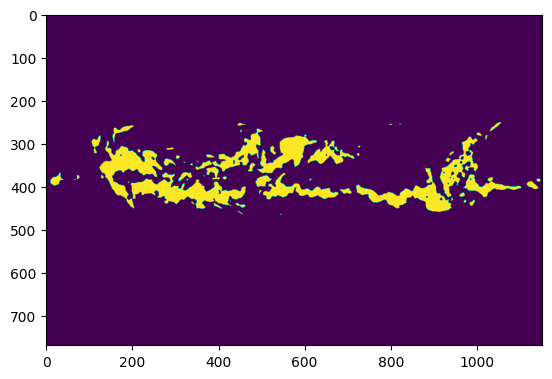

In [47]:
plt.imshow(laplacian_field<-11500)

In [48]:
import matplotlib.patches as patches
from skimage.feature import blob_log

Applying blob_log detector...


Detected 26 blobs.


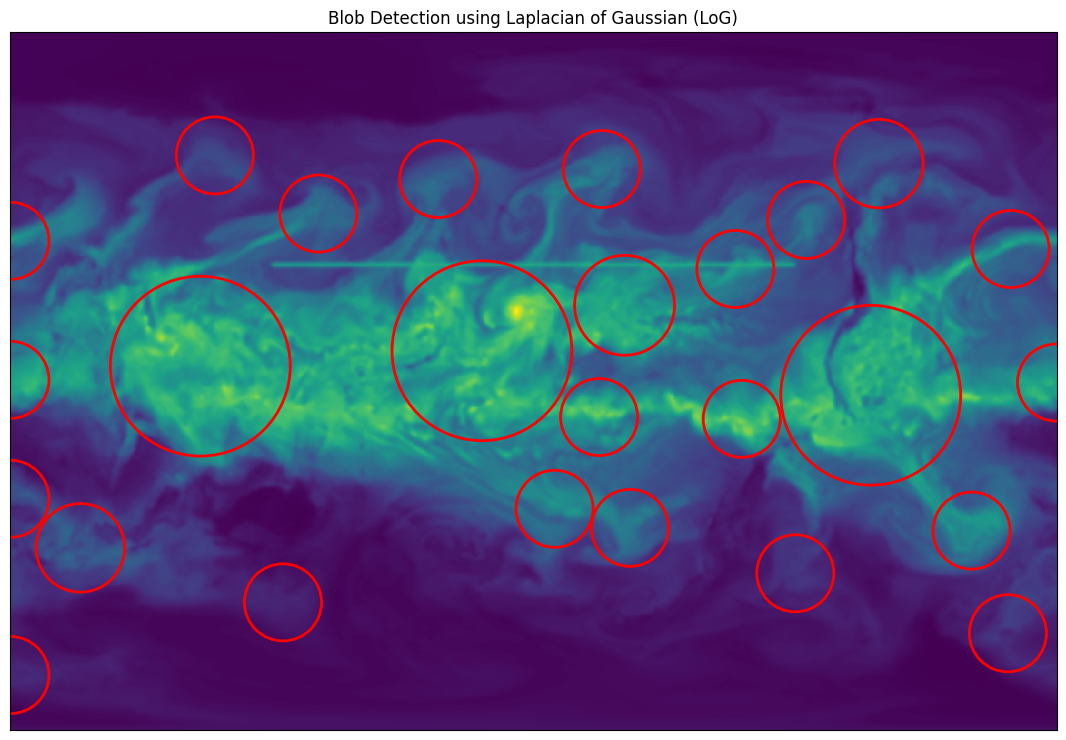

In [56]:
# --- 2. Apply the Laplacian of Gaussian (LoG) Blob Detector ---
print("Applying blob_log detector...")

# The parameters are key. We'll look for blobs with a radius
# between ~10 pixels (sigma=7) and ~40 pixels (sigma=28).
blobs = blob_log(
    selected_tmq_slice,
    min_sigma=30,
    max_sigma=70,
    num_sigma=10,
    threshold=2,  # Lower this to find fainter blobs
    overlap=0.     # Controls how much blobs can overlap
)

# The output `blobs` is an array with shape (n_blobs, 3)
# where columns are (y_center, x_center, sigma)
print(f"Detected {len(blobs)} blobs.")


# --- 3. Visualize the Results ---
# The visualization shows circles overlaid on the original image.
# The radius of each circle is derived from the 'sigma' found by the detector.
fig, ax = plt.subplots(1, 1, figsize=(15, 7.5))
ax.imshow(selected_tmq_slice, cmap='viridis', interpolation='nearest')

for blob in blobs:
    y, x, sigma = blob
    # Calculate the radius from sigma
    radius = sigma * np.sqrt(2)
    
    # Create a circle patch to draw on the image
    circle_patch = patches.Circle(
        (x, y), # (x, y) center
        radius,
        color='red',
        linewidth=2,
        fill=False
    )
    ax.add_patch(circle_patch)

ax.set_title('Blob Detection using Laplacian of Gaussian (LoG)')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

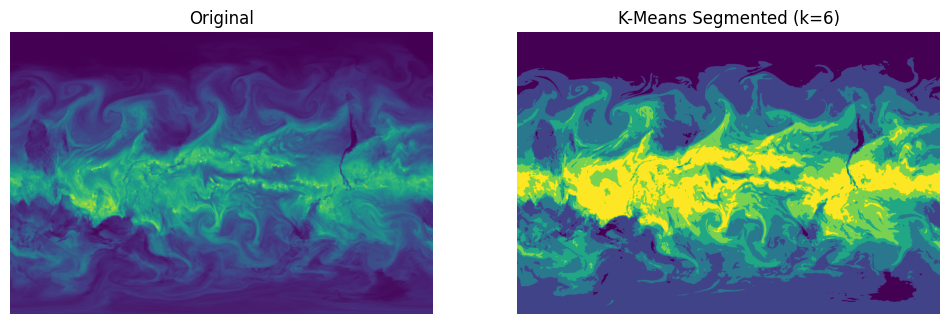

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Suppose img is your H x W grayscale image with values in [0, 1]
# For demonstration, let's create a dummy image:
# img = np.random.rand(H, W)
# Or load with: img = plt.imread('image.png') / 255.0 if it's grayscale
H,W = 768, 1152
# Step 1: Flatten the image
pixels = tmq_data[0,:,:].reshape(-1, 1)  # shape (H*W, 1)
pixels = (pixels-19.21859)/5.81723

# Step 2: Apply KMeans clustering
k = 6 # for example
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(pixels)

# # Step 3: Get the labels and reshape
# labels = kmeans.labels_.reshape(prob_map[0,:,:].shape)  # shape (H, W)

# # Optional: Replace each pixel with its cluster center for a quantized image
# clustered_img = kmeans.cluster_centers_[labels]


# Step 3: Sort the cluster centers and remap labels
# Get sorted indices of cluster centers
sorted_indices = np.argsort(kmeans.cluster_centers_.ravel())  # shape (k,)

# Map original labels to sorted labels
label_map = np.zeros_like(sorted_indices)
label_map[sorted_indices] = np.arange(k)

# Remap the labels
sorted_labels = label_map[kmeans.labels_]
sorted_labels_image = sorted_labels.reshape(H, W)



# Step 4: Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(tmq_data[0,:,:], cmap='viridis')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"K-Means Segmented (k={k})")
plt.imshow(sorted_labels_image, cmap='viridis')
plt.axis('off')
plt.show()

(array([2.43521e+05, 2.28265e+05, 1.39700e+05, 8.18670e+04, 6.55910e+04,
        6.48720e+04, 5.01460e+04, 9.12400e+03, 1.56000e+03, 9.00000e+01]),
 array([-1.23853004, -0.72182089, -0.20511174,  0.31159741,  0.82830656,
         1.34501576,  1.86172485,  2.37843394,  2.89514303,  3.41185236,
         3.92856145]),
 <BarContainer object of 10 artists>)

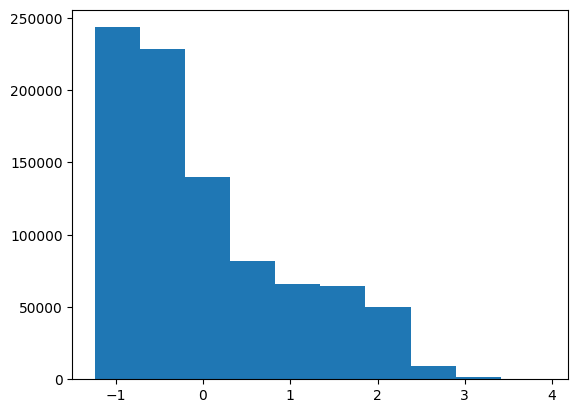

In [19]:
plt.hist(pixels)

In [25]:
log_resp = ndi.gaussian_laplace( tmq_data[0,:,:], sigma=2.0)
zero_x   = np.logical_and(log_resp > 0,
                          ndi.minimum_filter(log_resp, 3) < 0)

NameError: name 'ndi' is not defined

In [3]:
import scipy.ndimage as ndi

In [44]:
tmq_data.shape

(188, 768, 1152)

In [11]:
import numpy as np

# Let's assume your data is loaded into a NumPy array called tmq_data
# tmq_data = ... # Load your (16, 768, 1152) data here

# --- Step 1: Reshape the data for clustering ---
# The current shape is (images, height, width)
# We want to create a feature vector for each pixel (h, w) across all images.

# First, move the 'images' axis (axis 0) to the end.
# This changes the shape to (height, width, images) -> (768, 1152, 16)
print("Reshaping data...")
pixel_features = np.moveaxis(tmq_data, 0, -1)

# Now, flatten the height and width dimensions to create our 2D feature matrix
# The new shape will be (height * width, images) -> (884736, 16)
feature_matrix = pixel_features.reshape(-1, 188)

print(f"Created feature matrix with shape: {feature_matrix.shape}")

Reshaping data...
Created feature matrix with shape: (884736, 188)



Running the Elbow Method to find the optimal k...
  Testing k=2...
  Testing k=3...
  Testing k=4...
  Testing k=5...
  Testing k=6...
  Testing k=7...
  Testing k=8...
  Testing k=9...
  Testing k=10...


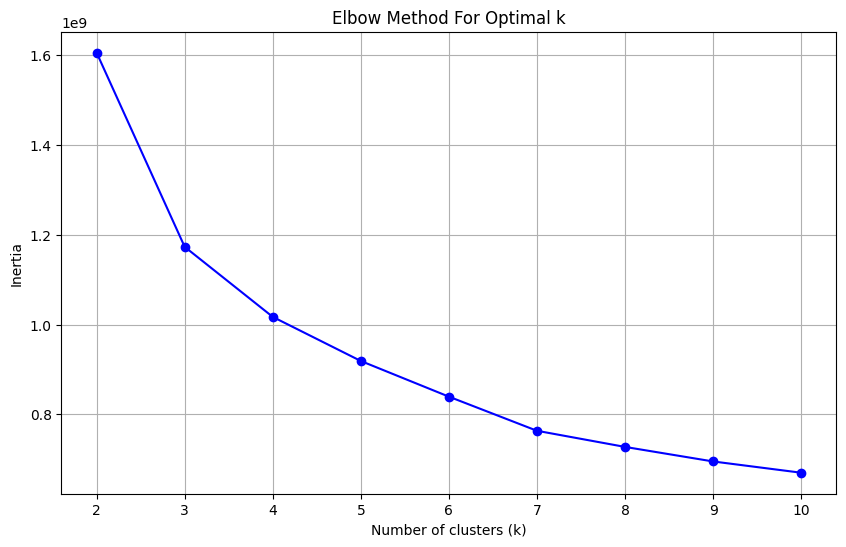

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print("\nRunning the Elbow Method to find the optimal k...")
inertia_values = []
# Let's test k from 2 to 10
k_range = range(2, 11)

# This process can be slow because the dataset is large.
# To speed it up for this diagnostic step, we can use a random sample of the data.
# Let's use 10% of the pixels.
subset_size = int(feature_matrix.shape[0] * 0.1)
feature_subset = feature_matrix[np.random.choice(feature_matrix.shape[0], subset_size, replace=False)]

for k in k_range:
    print(f"  Testing k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto', verbose=0)
    kmeans.fit(feature_subset)
    inertia_values.append(kmeans.inertia_)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [14]:
# Based on your elbow plot, let's say you chose k=4
optimal_k = 7

print(f"\nRunning final clustering on the full dataset with k={optimal_k}...")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto', verbose=1)
pixel_labels = kmeans.fit_predict(feature_matrix)

print("Clustering complete.")


Running final clustering on the full dataset with k=7...


Initialization complete
Iteration 0, inertia 13212377088.0.
Iteration 1, inertia 7883251200.0.
Iteration 2, inertia 7723250688.0.
Iteration 3, inertia 7678257664.0.
Iteration 4, inertia 7665455616.0.
Iteration 5, inertia 7656924672.0.
Iteration 6, inertia 7650393088.0.
Iteration 7, inertia 7645464576.0.
Iteration 8, inertia 7641992704.0.
Iteration 9, inertia 7639530496.0.
Iteration 10, inertia 7637727232.0.
Iteration 11, inertia 7636461568.0.
Iteration 12, inertia 7635586560.0.
Iteration 13, inertia 7634962432.0.
Iteration 14, inertia 7634566144.0.
Iteration 15, inertia 7634248704.0.
Iteration 16, inertia 7633993728.0.
Iteration 17, inertia 7633869312.0.
Iteration 18, inertia 7633784320.0.
Iteration 19, inertia 7633717760.0.
Iteration 20, inertia 7633690624.0.
Iteration 21, inertia 7633660416.0.
Iteration 22, inertia 7633649152.0.
Iteration 23, inertia 7633627648.0.
Iteration 24, inertia 7633587712.0.
Iteration 25, inertia 7633581056.0.
Iteration 26, inertia 7633575936.0.
Converged at 


✅ Final cluster map saved to 'tmq_based_cluster_map.npy'
Displaying final cluster map...


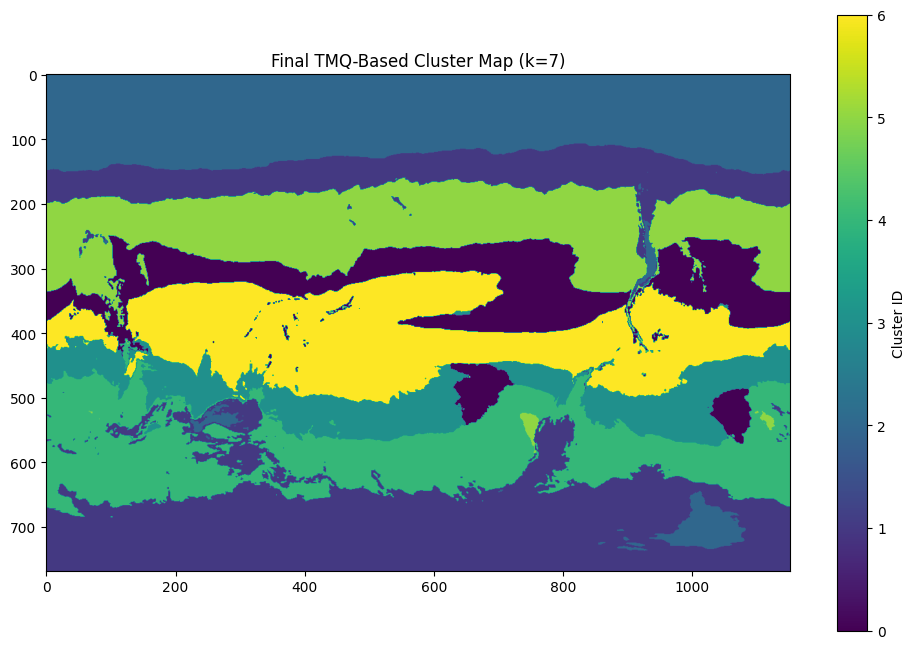

In [15]:
# Reshape the 1D array of labels back to the original image dimensions (H, W)
cluster_map = pixel_labels.reshape(768, 1152)

# --- Save the final map to a file ---
# This is the file you will load in your conformal calibration script
output_map_filename = "tmq_based_cluster_map.npy"
np.save(output_map_filename, cluster_map)
print(f"\n✅ Final cluster map saved to '{output_map_filename}'")


# --- Visualize the result to see if it makes intuitive sense ---
print("Displaying final cluster map...")
plt.figure(figsize=(12, 8))
plt.imshow(cluster_map, cmap='viridis') # 'viridis' is a good colormap for this
plt.colorbar(label='Cluster ID')
plt.title(f'Final TMQ-Based Cluster Map (k={optimal_k})')
plt.show()

In [41]:
pixel_labels.shape

(10395648,)

In [43]:
768*1152*16


14155776